In [0]:
patients_df = spark.read.csv(
    "/Volumes/shashank_databricks123/default/healthcare/patients.csv",
    header=True,
    inferSchema=True
)
patients_df.printSchema()
patients_df.show()

=== Patients Schema ===
root
 |-- patient_id: string (nullable = true)
 |-- patient_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- insurance_status: string (nullable = true)

+----------+------------+---------+-----------+---+------+----------------+
|patient_id|patient_name|     city|      state|age|gender|insurance_status|
+----------+------------+---------+-----------+---+------+----------------+
|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|
|      P102| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|
|      P103|  Amit Kumar|   Mumbai|Maharashtra| 42|  Male|        Inactive|
|      P104| Sneha Patel|    Delhi|      Delhi| 31|Female|          Active|
|      P105|  Farhan Ali|  Chennai| Tamil Nadu| 55|  Male|          Active|
|      P106|  Neha Singh|     Pune|Maharashtra| 38|Female|        Inactive|
|    

In [0]:
doctors_df = spark.read.csv(
    "/Volumes/shashank_databricks123/default/healthcare/doctors.csv",
    header=True,
    inferSchema=True
)
doctors_df.printSchema()
doctors_df.show()

root
 |-- doctor_id: string (nullable = true)
 |-- doctor_name: string (nullable = true)
 |-- department: string (nullable = true)
 |-- city: string (nullable = true)
 |-- consultation_fee: integer (nullable = true)

+---------+-----------+-----------+---------+----------------+
|doctor_id|doctor_name| department|     city|consultation_fee|
+---------+-----------+-----------+---------+----------------+
|     D101| Dr. Ramesh| Cardiology|Hyderabad|            1500|
|     D102|  Dr. Priya|  Neurology|Bangalore|            2000|
|     D103|  Dr. Anita|Dermatology|  Chennai|            1000|
|     D104| Dr. Suresh|Orthopedics|   Mumbai|            2500|
|     D105|  Dr. Meera| Pediatrics|    Delhi|            1200|
|     D106|  Dr. Kiran| Cardiology|Hyderabad|            3000|
+---------+-----------+-----------+---------+----------------+



In [0]:
appointments_df = spark.read.csv(
    "/Volumes/shashank_databricks123/default/healthcare/appointments.csv",
    header=True,
    inferSchema=True
)
appointments_df.printSchema()
appointments_df.show()

root
 |-- appointment_id: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- doctor_id: string (nullable = true)
 |-- appointment_date: date (nullable = true)
 |-- diagnosis: string (nullable = true)
 |-- bill_amount: integer (nullable = true)
 |-- status: string (nullable = true)

+--------------+----------+---------+----------------+--------------+-----------+---------+
|appointment_id|patient_id|doctor_id|appointment_date|     diagnosis|bill_amount|   status|
+--------------+----------+---------+----------------+--------------+-----------+---------+
|         A1001|      P101|     D101|      2026-06-01| Heart Checkup|       5000|Completed|
|         A1002|      P102|     D102|      2026-06-01|      Migraine|       3500|Completed|
|         A1003|      P103|     D103|      2026-06-02|  Skin Allergy|       2000|  Pending|
|         A1004|      P104|     D104|      2026-06-02|      Fracture|      12000|Completed|
|         A1005|      P105|     D105|      2026-06-0

In [0]:
preferences_raw_df = spark.read.option("multiline", "true").json(
    "/Volumes/shashank_databricks123/default/healthcare/patient_preferences.json"
)
preferences_raw_df.printSchema()
preferences_raw_df.show()

root
 |-- contact: struct (nullable = true)
 |    |-- email: string (nullable = true)
 |    |-- phone: string (nullable = true)
 |-- patient_id: string (nullable = true)
 |-- preferred_hospital: string (nullable = true)

+--------------------+----------+------------------+
|             contact|patient_id|preferred_hospital|
+--------------------+----------+------------------+
|{rahul@mail.com, ...|      P101|   Apollo Hospital|
|{priya@mail.com, ...|      P102|  Yashoda Hospital|
|{sneha@mail.com, ...|      P104|     Care Hospital|
|{meera@mail.com, ...|      P108|   Apollo Hospital|
+--------------------+----------+------------------+



In [0]:
patients_df.write.format("delta").mode("overwrite").saveAsTable("bronze_patients")
doctors_df.write.format("delta").mode("overwrite").saveAsTable("bronze_doctors")
appointments_df.write.format("delta").mode("overwrite").saveAsTable("bronze_appointments")
preferences_raw_df.write.format("delta").mode("overwrite").saveAsTable("bronze_patient_preferences")
print("All Bronze Delta tables saved successfully.")

All Bronze Delta tables saved successfully.


In [0]:
from pyspark.sql.functions import (
    col, when, lit, to_date, date_format,
    month, year, coalesce
)

In [0]:
patients_clean_df = patients_df \
    .fillna({"city": "Unknown", "state": "Unknown", "gender": "Unknown", "insurance_status": "Unknown"}) \
    .dropna(subset=["patient_id"])

In [0]:
doctors_clean_df = doctors_df \
    .fillna({"department": "General", "city": "Unknown"}) \
    .dropna(subset=["doctor_id"])

In [0]:
appointments_clean_df = appointments_df \
    .fillna({"status": "Unknown", "bill_amount": 0}) \
    .dropna(subset=["appointment_id"])

In [0]:
print("Missing values handled.")
patients_clean_df.show()

Missing values handled.
+----------+------------+---------+-----------+---+------+----------------+
|patient_id|patient_name|     city|      state|age|gender|insurance_status|
+----------+------------+---------+-----------+---+------+----------------+
|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|
|      P102| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|
|      P103|  Amit Kumar|   Mumbai|Maharashtra| 42|  Male|        Inactive|
|      P104| Sneha Patel|    Delhi|      Delhi| 31|Female|          Active|
|      P105|  Farhan Ali|  Chennai| Tamil Nadu| 55|  Male|          Active|
|      P106|  Neha Singh|     Pune|Maharashtra| 38|Female|        Inactive|
|      P107| Arjun Verma|Hyderabad|  Telangana| 26|  Male|          Active|
|      P108|  Meera Nair|    Kochi|     Kerala| 48|Female|          Active|
+----------+------------+---------+-----------+---+------+----------------+



In [0]:
preferences_flat_df = preferences_raw_df.select(
    col("patient_id"),
    col("preferred_hospital"),
    col("contact.phone").alias("phone"),
    col("contact.email").alias("email")
)
print("Flattened Preferences")
preferences_flat_df.show()

Flattened Preferences
+----------+------------------+----------+--------------+
|patient_id|preferred_hospital|     phone|         email|
+----------+------------------+----------+--------------+
|      P101|   Apollo Hospital|9876500011|rahul@mail.com|
|      P102|  Yashoda Hospital|9876500012|priya@mail.com|
|      P104|     Care Hospital|9876500014|sneha@mail.com|
|      P108|   Apollo Hospital|9876500018|meera@mail.com|
+----------+------------------+----------+--------------+



In [0]:
patients_with_prefs_df = patients_clean_df.join(
    preferences_flat_df, on="patient_id", how="left"
)
print("Patients with Preferences")
patients_with_prefs_df.show()

Patients with Preferences
+----------+------------+---------+-----------+---+------+----------------+------------------+----------+--------------+
|patient_id|patient_name|     city|      state|age|gender|insurance_status|preferred_hospital|     phone|         email|
+----------+------------+---------+-----------+---+------+----------------+------------------+----------+--------------+
|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|   Apollo Hospital|9876500011|rahul@mail.com|
|      P102| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|  Yashoda Hospital|9876500012|priya@mail.com|
|      P103|  Amit Kumar|   Mumbai|Maharashtra| 42|  Male|        Inactive|              NULL|      NULL|          NULL|
|      P104| Sneha Patel|    Delhi|      Delhi| 31|Female|          Active|     Care Hospital|9876500014|sneha@mail.com|
|      P105|  Farhan Ali|  Chennai| Tamil Nadu| 55|  Male|          Active|              NULL|      NULL|          NULL|
|     

In [0]:
appt_patients_df = appointments_clean_df.join(
    patients_clean_df, on="patient_id", how="left"
)
print("Appointments + Patients")
appt_patients_df.show()


Appointments + Patients
+----------+--------------+---------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+
|patient_id|appointment_id|doctor_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|     city|      state|age|gender|insurance_status|
+----------+--------------+---------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+
|      P101|         A1001|     D101|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|
|      P102|         A1002|     D102|      2026-06-01|      Migraine|       3500|Completed| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|
|      P103|         A1003|     D103|      2026-06-02|  Skin Allergy|       2000|  Pending|  Amit Kumar|   Mumbai|Maharashtra| 42|  Male|        Inactive|
|      P104|         A1004|     D104|      202

In [0]:
doctors_renamed_df = doctors_clean_df.withColumnRenamed(
    "city",
    "doctor_city"
)

appt_full_df = appt_patients_df.join(
    doctors_renamed_df,
    on="doctor_id",
    how="left"
)

appt_full_df.show()

+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|     city|      state|age|gender|insurance_status|doctor_name| department|doctor_city|consultation_fee|
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+
|     D101|      P101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|  Hyderabad|            1500|
|     D102|      P102|         A1002|      2026-06-01|      Migraine|       3500|Completed| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|  Dr. Priya|  

In [0]:
appt_transformed_df = appt_full_df \
.withColumn(
    "final_bill",
    col("bill_amount") + col("consultation_fee")
) \
.withColumn(
    "appointment_month",
    month("appointment_date")
) \
.withColumn(
    "patient_age_group",
    when(col("age") >= 50, "Senior")
    .when(col("age") >= 30, "Adult")
    .otherwise("Young")
)
print("Transformed Appointments")
appt_transformed_df.show()

Transformed Appointments
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|     city|      state|age|gender|insurance_status|doctor_name| department|doctor_city|consultation_fee|final_bill|appointment_month|patient_age_group|
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|     D101|      P101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|  Hyderabad|            1500|   

In [0]:
appt_transformed_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("silver_appointments")

In [0]:
patients_with_prefs_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("silver_patients")

In [0]:
doctors_renamed_df.write \
.format("delta") \
.mode("overwrite") \
.saveAsTable("silver_doctors")

In [0]:
appt_transformed_df.createOrReplaceTempView("appointments_view")
patients_with_prefs_df.createOrReplaceTempView("patients_view")
doctors_clean_df.createOrReplaceTempView("doctors_view")

In [0]:
total_revenue_df = spark.sql("""
    SELECT
        SUM(final_bill) AS total_hospital_revenue
    FROM appointments_view
    WHERE status = 'Completed'
""")
print("Total Hospital Revenue")
total_revenue_df.show()

Total Hospital Revenue
+----------------------+
|total_hospital_revenue|
+----------------------+
|                 55700|
+----------------------+



In [0]:
revenue_by_dept_df = spark.sql("""
    SELECT
        department,
        SUM(final_bill) AS total_revenue,
        COUNT(appointment_id) AS total_appointments
    FROM appointments_view
    WHERE status = 'Completed'
    GROUP BY department
    ORDER BY total_revenue DESC
""")
print("Revenue by Department")
revenue_by_dept_df.show()

Revenue by Department
+-----------+-------------+------------------+
| department|total_revenue|total_appointments|
+-----------+-------------+------------------+
| Cardiology|        33000|                 4|
|Orthopedics|        14500|                 1|
|  Neurology|         5500|                 1|
| Pediatrics|         2700|                 1|
+-----------+-------------+------------------+



In [0]:
revenue_by_city_df = spark.sql("""
    SELECT
        city,
        SUM(final_bill) AS total_revenue,
        COUNT(appointment_id) AS total_appointments
    FROM appointments_view
    WHERE status = 'Completed'
    GROUP BY city
    ORDER BY total_revenue DESC
""")
print("Revenue by City")
revenue_by_city_df.show()

Revenue by City
+---------+-------------+------------------+
|     city|total_revenue|total_appointments|
+---------+-------------+------------------+
|Hyderabad|        23000|                 3|
|    Delhi|        14500|                 1|
|     Pune|        10000|                 1|
|Bangalore|         5500|                 1|
|  Chennai|         2700|                 1|
+---------+-------------+------------------+



In [0]:
completed_appts_df = spark.sql("""
    SELECT
        appointment_id, patient_name, doctor_name, department,
        appointment_date, diagnosis, bill_amount, consultation_fee,
        final_bill, status
    FROM appointments_view
    WHERE status = 'Completed'
    ORDER BY appointment_date
""")
print("Completed Appointments")
completed_appts_df.show()

Completed Appointments
+--------------+------------+-----------+-----------+----------------+--------------+-----------+----------------+----------+---------+
|appointment_id|patient_name|doctor_name| department|appointment_date|     diagnosis|bill_amount|consultation_fee|final_bill|   status|
+--------------+------------+-----------+-----------+----------------+--------------+-----------+----------------+----------+---------+
|         A1001|Rahul Sharma| Dr. Ramesh| Cardiology|      2026-06-01| Heart Checkup|       5000|            1500|      6500|Completed|
|         A1002| Priya Reddy|  Dr. Priya|  Neurology|      2026-06-01|      Migraine|       3500|            2000|      5500|Completed|
|         A1004| Sneha Patel| Dr. Suresh|Orthopedics|      2026-06-02|      Fracture|      12000|            2500|     14500|Completed|
|         A1005|  Farhan Ali|  Dr. Meera| Pediatrics|      2026-06-03|         Fever|       1500|            1200|      2700|Completed|
|         A1006|  Neha Si

In [0]:
top_patients_df = spark.sql("""
    SELECT
        patient_id,
        patient_name,
        SUM(final_bill) AS total_billed,
        COUNT(appointment_id) AS total_appointments
    FROM appointments_view
    GROUP BY patient_id, patient_name
    ORDER BY total_billed DESC
""")
print("Top Patients by Billing")
top_patients_df.show()


Top Patients by Billing
+----------+------------+------------+------------------+
|patient_id|patient_name|total_billed|total_appointments|
+----------+------------+------------+------------------+
|      P104| Sneha Patel|       21500|                 2|
|      P101|Rahul Sharma|       16000|                 2|
|      P106|  Neha Singh|       10000|                 1|
|      P107| Arjun Verma|        7000|                 1|
|      P102| Priya Reddy|        5500|                 1|
|      P108|  Meera Nair|        3500|                 1|
|      P103|  Amit Kumar|        3000|                 1|
|      P105|  Farhan Ali|        2700|                 1|
+----------+------------+------------+------------------+



In [0]:
from pyspark.sql.functions import rank, dense_rank, sum as spark_sum, row_number
from pyspark.sql.window import Window

In [0]:
import warnings
warnings.filterwarnings("ignore")

In [0]:
doctor_revenue_df = appt_transformed_df.groupBy("doctor_id", "doctor_name", "department") \
    .agg(spark_sum("final_bill").alias("total_revenue"))
doctor_window = Window.orderBy(col("total_revenue").desc())
ranked_doctors_df = doctor_revenue_df.withColumn(
    "revenue_rank", rank().over(doctor_window)
)
print("Doctors Ranked by Revenue")
ranked_doctors_df.show()

Doctors Ranked by Revenue
+---------+-----------+-----------+-------------+------------+
|doctor_id|doctor_name| department|total_revenue|revenue_rank|
+---------+-----------+-----------+-------------+------------+
|     D104| Dr. Suresh|Orthopedics|        21500|           1|
|     D106|  Dr. Kiran| Cardiology|        19500|           2|
|     D101| Dr. Ramesh| Cardiology|        13500|           3|
|     D103|  Dr. Anita|Dermatology|         6500|           4|
|     D102|  Dr. Priya|  Neurology|         5500|           5|
|     D105|  Dr. Meera| Pediatrics|         2700|           6|
+---------+-----------+-----------+-------------+------------+



In [0]:
dept_revenue_df = appt_transformed_df.groupBy("department") \
    .agg(spark_sum("final_bill").alias("total_revenue"))
dept_window = Window.orderBy(col("total_revenue").desc())
ranked_depts_df = dept_revenue_df.withColumn(
    "dept_rank", rank().over(dept_window)
)
print("Departments Ranked by Revenue")
ranked_depts_df.show()

Departments Ranked by Revenue
+-----------+-------------+---------+
| department|total_revenue|dept_rank|
+-----------+-------------+---------+
| Cardiology|        33000|        1|
|Orthopedics|        21500|        2|
|Dermatology|         6500|        3|
|  Neurology|         5500|        4|
| Pediatrics|         2700|        5|
+-----------+-------------+---------+



In [0]:
patient_bill_df = appt_transformed_df.groupBy("patient_id", "patient_name") \
    .agg(spark_sum("final_bill").alias("total_billed"))
patient_window = Window.orderBy(col("total_billed").desc())
top3_patients_df = patient_bill_df \
    .withColumn("billing_rank", rank().over(patient_window)) \
    .filter(col("billing_rank") <= 3)
print("Top 3 Patients by Billing")
top3_patients_df.show()

Top 3 Patients by Billing
+----------+------------+------------+------------+
|patient_id|patient_name|total_billed|billing_rank|
+----------+------------+------------+------------+
|      P104| Sneha Patel|       21500|           1|
|      P101|Rahul Sharma|       16000|           2|
|      P106|  Neha Singh|       10000|           3|
+----------+------------+------------+------------+



In [0]:
dept_doctor_window = Window.partitionBy("department").orderBy(col("total_revenue").desc())
top_doctor_per_dept_df = doctor_revenue_df \
    .withColumn("rank_in_dept", row_number().over(dept_doctor_window)) \
    .filter(col("rank_in_dept") == 1) \
    .drop("rank_in_dept")
print("Top Doctor in Each Department")
top_doctor_per_dept_df.show()

Top Doctor in Each Department
+---------+-----------+-----------+-------------+
|doctor_id|doctor_name| department|total_revenue|
+---------+-----------+-----------+-------------+
|     D106|  Dr. Kiran| Cardiology|        19500|
|     D103|  Dr. Anita|Dermatology|         6500|
|     D102|  Dr. Priya|  Neurology|         5500|
|     D104| Dr. Suresh|Orthopedics|        21500|
|     D105|  Dr. Meera| Pediatrics|         2700|
+---------+-----------+-----------+-------------+



In [0]:
from pyspark.sql.functions import sum as spark_sum

In [0]:
daily_revenue_df = appt_transformed_df.groupBy("appointment_date") \
    .agg(spark_sum("final_bill").alias("daily_revenue")) \
    .orderBy("appointment_date")
running_window = Window.orderBy("appointment_date").rowsBetween(Window.unboundedPreceding, Window.currentRow)
running_revenue_df = daily_revenue_df.withColumn(
    "running_total_revenue", spark_sum("daily_revenue").over(running_window)
)
print("Running Revenue by Date")
running_revenue_df.show()

Running Revenue by Date
+----------------+-------------+---------------------+
|appointment_date|daily_revenue|running_total_revenue|
+----------------+-------------+---------------------+
|      2026-06-01|        12000|                12000|
|      2026-06-02|        17500|                29500|
|      2026-06-03|        12700|                42200|
|      2026-06-04|        10500|                52700|
|      2026-06-05|        16500|                69200|
+----------------+-------------+---------------------+



In [0]:
appt_transformed_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/Volumes/shashank_databricks123/default/healthcare/appointments_delta")
 
print("Delta table written to path: /Volumes/shashank_databricks123/default/healthcare/appointments_delta")

Delta table written to path: /Volumes/shashank_databricks123/default/healthcare/appointments_delta


In [0]:
appt_transformed_df.write \
    .format("delta") \
    .mode("overwrite") \
    .saveAsTable("gold_appointments")
print("Delta table created using saveAsTable(): gold_appointments")

Delta table created using saveAsTable(): gold_appointments


In [0]:
spark.sql("""
    CREATE TABLE IF NOT EXISTS gold_appointments_sql
    USING DELTA
    AS
    SELECT * FROM silver_appointments
""")
print("Delta table created using SQL: gold_appointments_sql")

Delta table created using SQL: gold_appointments_sql


In [0]:
spark.sql("DESCRIBE HISTORY gold_appointments").show(truncate=False)

+-------+-------------------+---------------+-------------------------------------------------------+---------------------------------+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+------------------+------------------------------------+------------------------+-----------+-----------------+-------------+----------------------------------------------------------------------------------------------------------------------------------------+------------+------------------------------------------+
|version|timestamp          |userId         |userName                                               |operation                        |operationParameters                                                                                                                                                                

In [0]:
old_version_df = spark.read.format("delta") \
    .option("versionAsOf", 0) \
    .table("gold_appointments")
 
print("Time Travel: Version 0 of gold_appointments")
old_version_df.show()

Time Travel: Version 0 of gold_appointments
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|doctor_id|patient_id|appointment_id|appointment_date|     diagnosis|bill_amount|   status|patient_name|     city|      state|age|gender|insurance_status|doctor_name| department|doctor_city|consultation_fee|final_bill|appointment_month|patient_age_group|
+---------+----------+--------------+----------------+--------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|     D101|      P101|         A1001|      2026-06-01| Heart Checkup|       5000|Completed|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|  Hyderabad| 

In [0]:
from delta.tables import DeltaTable

In [0]:
updated_patients_data = [
    ("P103", "Nagpur", "Maharashtra", 42, "Male", "Active"),   # city + insurance changed
    ("P106", "Nashik", "Maharashtra", 38, "Female", "Active"), # city + insurance changed
    ("P109", "Surat", "Gujarat", 33, "Male", "Active")         # new patient
]
updated_patients_df = spark.createDataFrame(
    updated_patients_data,
    ["patient_id", "city", "state", "age", "gender", "insurance_status"]
)

In [0]:
delta_table = DeltaTable.forName(spark, "silver_patients")
delta_table.alias("target").merge(
    updated_patients_df.alias("source"),
    "target.patient_id = source.patient_id"
).whenMatchedUpdate(set={
    "city":             "source.city",
    "state":            "source.state",
    "insurance_status": "source.insurance_status"
}).whenNotMatchedInsert(values={
    "patient_id":        "source.patient_id",
    "patient_name":      "'Unknown'",
    "city":              "source.city",
    "state":             "source.state",
    "age":               "source.age",
    "gender":            "source.gender",
    "insurance_status":  "source.insurance_status"
}).execute()
spark.table("silver_patients").show()

+----------+------------+---------+-----------+---+------+----------------+------------------+----------+--------------+
|patient_id|patient_name|     city|      state|age|gender|insurance_status|preferred_hospital|     phone|         email|
+----------+------------+---------+-----------+---+------+----------------+------------------+----------+--------------+
|      P101|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active|   Apollo Hospital|9876500011|rahul@mail.com|
|      P102| Priya Reddy|Bangalore|  Karnataka| 29|Female|          Active|  Yashoda Hospital|9876500012|priya@mail.com|
|      P104| Sneha Patel|    Delhi|      Delhi| 31|Female|          Active|     Care Hospital|9876500014|sneha@mail.com|
|      P105|  Farhan Ali|  Chennai| Tamil Nadu| 55|  Male|          Active|              NULL|      NULL|          NULL|
|      P107| Arjun Verma|Hyderabad|  Telangana| 26|  Male|          Active|              NULL|      NULL|          NULL|
|      P108|  Meera Nair|    Koc

In [0]:
spark.sql("DESCRIBE HISTORY silver_patients").show(5, truncate=False)

+-------+-------------------+---------------+-------------------------------------------------------+---------------------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+----+------------------+------------------------------------+------------------------+-----------+-----------------+-------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [0]:
spark.sql("OPTIMIZE silver_appointments")
print("OPTIMIZE completed on silver_appointments.")

OPTIMIZE completed on silver_appointments.


In [0]:
spark.sql("OPTIMIZE silver_appointments ZORDER BY (patient_id)")
print("ZORDER BY patient_id completed on silver_appointments.")

ZORDER BY patient_id completed on silver_appointments.


In [0]:
spark.sql("VACUUM silver_appointments RETAIN 168 HOURS")
print("✅ VACUUM completed on silver_appointments (168 hours / 7 days retention).")

✅ VACUUM completed on silver_appointments (168 hours / 7 days retention).


In [0]:
import matplotlib.pyplot as plt
import pandas as pd

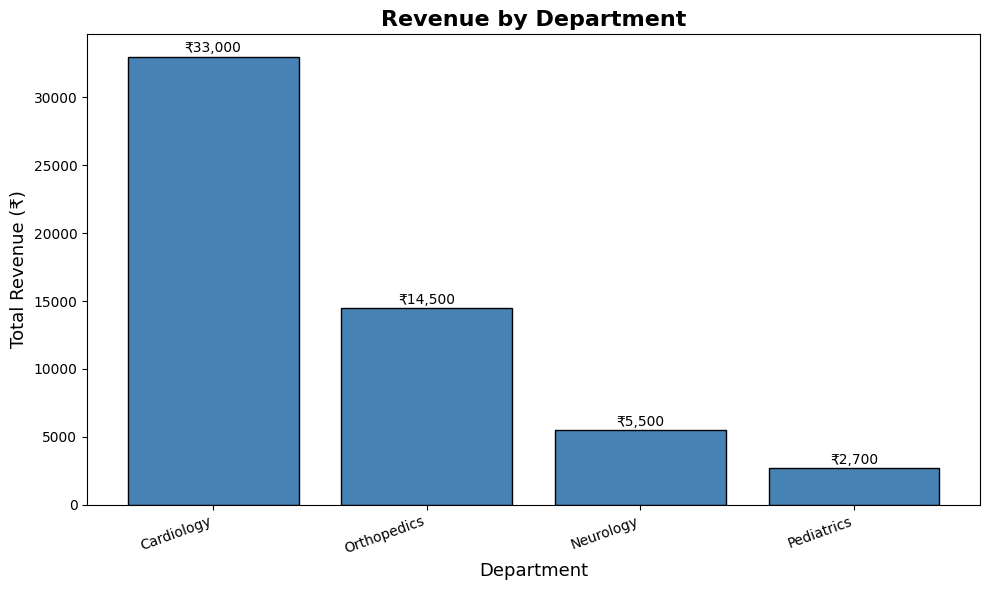

In [0]:
dept_pd = revenue_by_dept_df.toPandas()
plt.figure(figsize=(10, 6))
bars = plt.bar(dept_pd["department"], dept_pd["total_revenue"], color="steelblue", edgecolor="black")
plt.title("Revenue by Department", fontsize=16, fontweight="bold")
plt.xlabel("Department", fontsize=13)
plt.ylabel("Total Revenue (₹)", fontsize=13)
plt.xticks(rotation=20, ha="right")
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f"₹{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

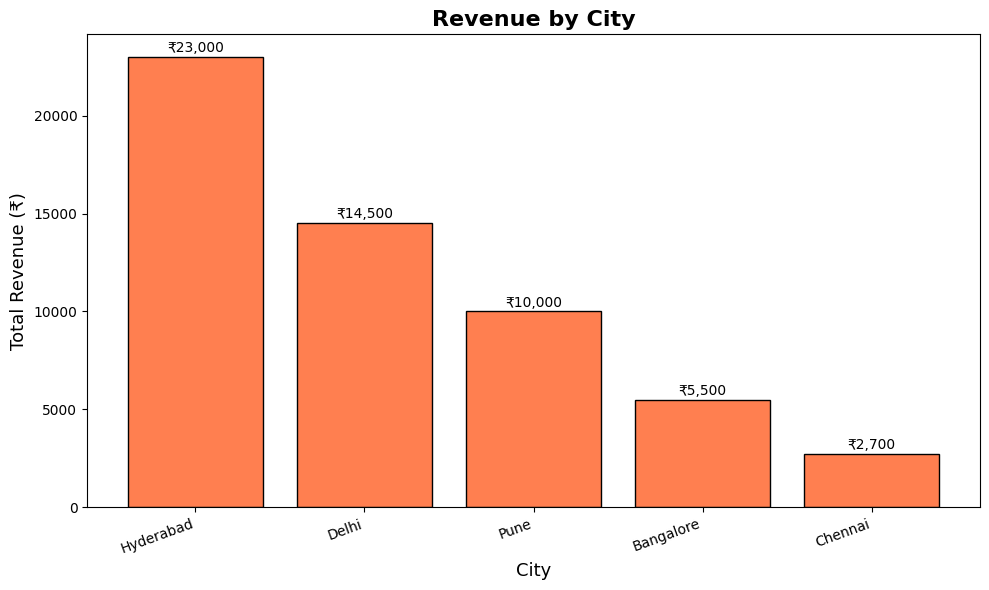

In [0]:
city_pd = revenue_by_city_df.toPandas()
plt.figure(figsize=(10, 6))
bars = plt.bar(city_pd["city"], city_pd["total_revenue"], color="coral", edgecolor="black")
plt.title("Revenue by City", fontsize=16, fontweight="bold")
plt.xlabel("City", fontsize=13)
plt.ylabel("Total Revenue (₹)", fontsize=13)
plt.xticks(rotation=20, ha="right")
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f"₹{int(bar.get_height()):,}", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()


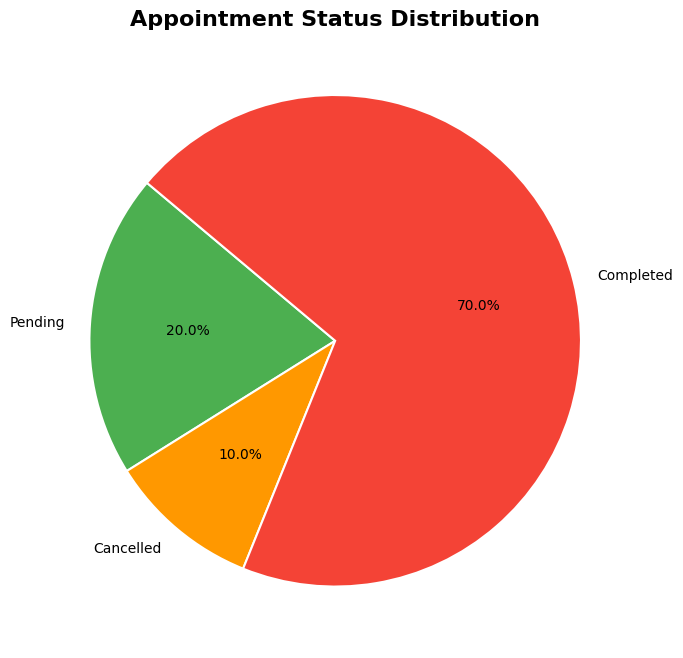

In [0]:
status_pd = appt_transformed_df.groupBy("status") \
    .count().toPandas()
 
colors = ["#4CAF50", "#FF9800", "#F44336"]
plt.figure(figsize=(7, 7))
plt.pie(
    status_pd["count"],
    labels=status_pd["status"],
    autopct="%1.1f%%",
    colors=colors,
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5}
)
plt.title("Appointment Status Distribution", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

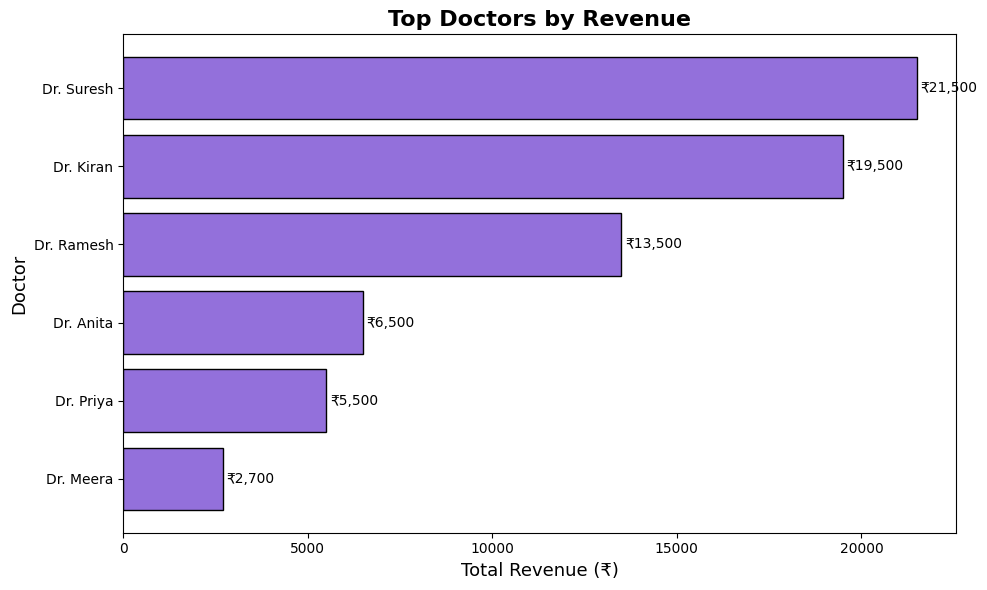

In [0]:
doc_pd = ranked_doctors_df.orderBy("revenue_rank").toPandas()
plt.figure(figsize=(10, 6))
bars = plt.barh(doc_pd["doctor_name"], doc_pd["total_revenue"], color="mediumpurple", edgecolor="black")
plt.title("Top Doctors by Revenue", fontsize=16, fontweight="bold")
plt.xlabel("Total Revenue (₹)", fontsize=13)
plt.ylabel("Doctor", fontsize=13)
for bar in bars:
    plt.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f"₹{int(bar.get_width()):,}", va="center", fontsize=10)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

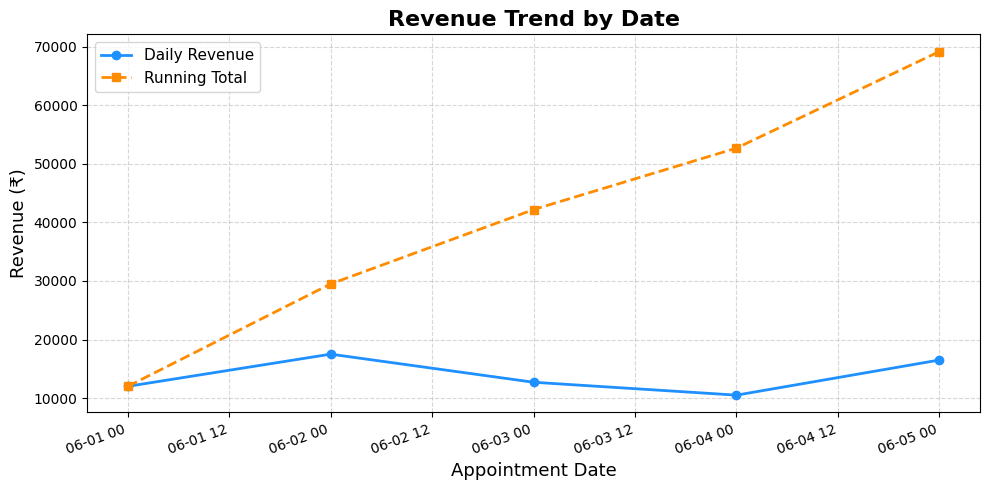

In [0]:
trend_pd = running_revenue_df.toPandas()
trend_pd["appointment_date"] = pd.to_datetime(trend_pd["appointment_date"])
 
plt.figure(figsize=(10, 5))
plt.plot(trend_pd["appointment_date"], trend_pd["daily_revenue"],
         marker="o", color="dodgerblue", linewidth=2, label="Daily Revenue")
plt.plot(trend_pd["appointment_date"], trend_pd["running_total_revenue"],
         marker="s", color="darkorange", linewidth=2, linestyle="--", label="Running Total")
plt.title("Revenue Trend by Date", fontsize=16, fontweight="bold")
plt.xlabel("Appointment Date", fontsize=13)
plt.ylabel("Revenue (₹)", fontsize=13)
plt.legend(fontsize=11)
plt.xticks(rotation=20, ha="right")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [0]:
spark.sql("""
    CREATE TABLE IF NOT EXISTS managed_appointments
    USING DELTA
    AS SELECT * FROM silver_appointments
""")
print("Managed Table created: managed_appointments")

Managed Table created: managed_appointments


In [0]:
appt_transformed_df.write \
    .format("delta") \
    .mode("overwrite") \
    .save("/Volumes/shashank_databricks123/default/healthcare/external_appointments")
 
spark.sql("""
    CREATE TABLE IF NOT EXISTS external_appointments
    AS SELECT * FROM delta.`/Volumes/shashank_databricks123/default/healthcare/external_appointments`
""")
print("External Table created: external_appointments")

External Table created: external_appointments


In [0]:
appt_transformed_df.createOrReplaceTempView("temp_appointments_view")
print("Temporary View created: temp_appointments_view")
spark.sql("SELECT * FROM temp_appointments_view LIMIT 3").show()

Temporary View created: temp_appointments_view
+---------+----------+--------------+----------------+-------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|doctor_id|patient_id|appointment_id|appointment_date|    diagnosis|bill_amount|   status|patient_name|     city|      state|age|gender|insurance_status|doctor_name| department|doctor_city|consultation_fee|final_bill|appointment_month|patient_age_group|
+---------+----------+--------------+----------------+-------------+-----------+---------+------------+---------+-----------+---+------+----------------+-----------+-----------+-----------+----------------+----------+-----------------+-----------------+
|     D101|      P101|         A1001|      2026-06-01|Heart Checkup|       5000|Completed|Rahul Sharma|Hyderabad|  Telangana| 35|  Male|          Active| Dr. Ramesh| Cardiology|  Hyderabad|  

In [0]:
comparison = [
    ("Managed Table",
     "All notebooks/sessions",
     "Persists until dropped"),

    ("External Table",
     "All notebooks/sessions",
     "Metadata removed on drop; data remains"),

    ("Temporary View",
     "Current session only",
     "Removed when session ends"),

    ("Global Temporary View",
     "All sessions in Spark app",
     "Removed when Spark app stops")
]
columns = ["Object Type", "Scope", "Lifetime"]
comparison_df = spark.createDataFrame(comparison, columns)
display(comparison_df)

Object Type,Scope,Lifetime
Managed Table,All notebooks/sessions,Persists until dropped
External Table,All notebooks/sessions,Metadata removed on drop; data remains
Temporary View,Current session only,Removed when session ends
Global Temporary View,All sessions in Spark app,Removed when Spark app stops
